In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
import numpy as np
df = pd.read_csv("/content/placement_predict_50k Dataset (1) (1).csv")
target_col = "CGPA"
drop_cols = [target_col, "StudentID", "CGPA_Tier"]
y = df[target_col].values.reshape(-1, 1)
feature_df = df.drop(columns=drop_cols).select_dtypes(include=[np.number])
feature_df = feature_df.fillna(feature_df.median())

X = feature_df.values

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train_b = np.c_[np.ones((x_train.shape[0], 1)), x_train]
x_test_b = np.c_[np.ones((x_test.shape[0], 1)), x_test]

In [ ]:
def gradient_descent(x, y, lr=0.01, n_iters=1000):
  m, n = x.shape
  theta = np.zeros((n, 1)) # Corrected typo: zeroes -> zeros
  losses = [] # Initialize losses list
  for i in range(n_iters):
    y_pred = x @ theta
    error = y_pred - y
    loss = (1 / (2 * m)) * np.sum(error ** 2)
    losses.append(loss)
    gradient = (1 / m) * (x.T @ error) # Corrected typo: x.t -> x.T
    theta -= lr * gradient

    if i % 100 == 0:
      print(f"Iteration {i:4d}: loss={loss:.4f}")
  return theta, losses # Move return statement outside the loop

theta, losses = gradient_descent(x_train_b, y_train, lr=0.01, n_iters=1000)

Iteration    0: loss=27.5449
Iteration  100: loss=3.6433
Iteration  200: loss=0.5801
Iteration  300: loss=0.1658
Iteration  400: loss=0.1086
Iteration  500: loss=0.1002
Iteration  600: loss=0.0987
Iteration  700: loss=0.0983
Iteration  800: loss=0.0981
Iteration  900: loss=0.0980


In [ ]:
y_pred = x_test_b @ theta
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nFinal weights (theta):")
print(theta.ravel())
print(f"\nMean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")


Final weights (theta):
[ 7.24382401  0.22693764  0.2125424   0.19921983  0.19250102  0.17573198
  0.16200885  0.16057318  0.14754696  0.04332808  0.0722388   0.09582867
 -0.09912156 -0.14002453 -0.06255981  0.21440539 -0.09160291  0.37303718
 -0.16831104 -0.01783629 -0.0843323  -0.03506336]

Mean Squared Error: 0.2058
R-squared: 0.9209


In [ ]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(x_train, y_train)
sk_y_pred = sk_model.predict(x_test)


Saved plots to gradient_descent_plots.png


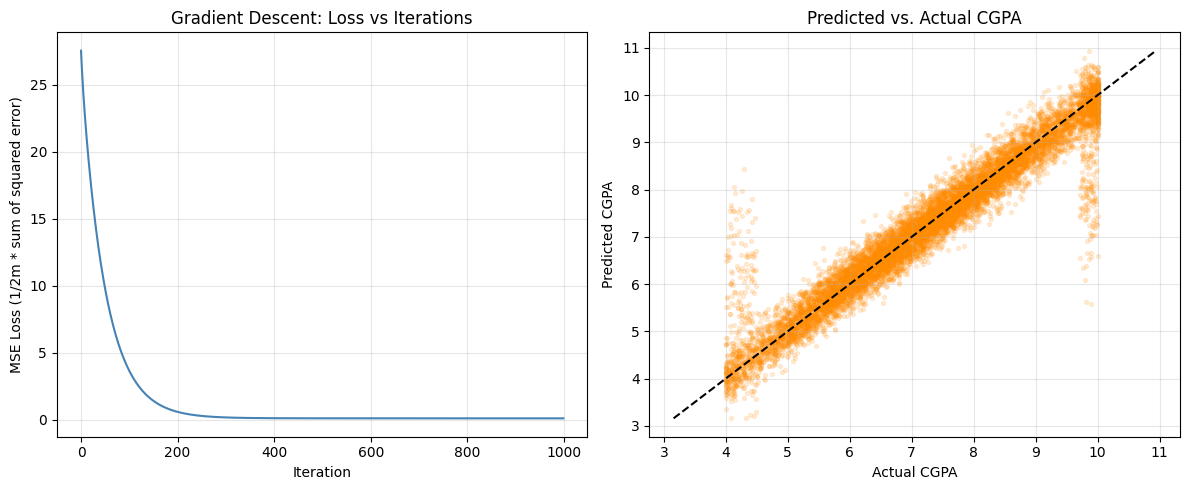

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(range(len(losses)), losses, color="steelblue")
axes[0].set_title("Gradient Descent: Loss vs Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE Loss (1/2m * sum of squared error)")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, y_pred, alpha=0.15, s=8, color="darkorange")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, color="black", linestyle="--")
axes[1].set_title("Predicted vs. Actual CGPA")
axes[1].set_xlabel("Actual CGPA")
axes[1].set_ylabel("Predicted CGPA")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gradient_descent_results.png", dpi=150)
print("\nSaved plots to gradient_descent_plots.png")
plt.show()